In [ ]:
import pandas as pd
import os
print("Files uploaded:")
print(os.listdir())

Files uploaded:
['.config', '05_category_inflows.csv', '08_investor_transactions.csv', '02_nav_history.csv', '07_scheme_performance.csv', '.ipynb_checkpoints', '04_monthly_sip_inflows.csv', '10_benchmark_indices.csv', '03_aum_by_fund_house.csv', '09_portfolio_holdings.csv', '01_fund_master.csv', '06_industry_folio_count.csv', 'sample_data']


In [ ]:
import pandas as pd

files = [
    "01_fund_master.csv",
    "02_nav_history.csv",
    "03_aum_by_fund_house.csv",
    "04_monthly_sip_inflows.csv",
    "05_category_inflows.csv",
    "06_industry_folio_count.csv",
    "07_scheme_performance.csv",
    "08_investor_transactions.csv",
    "09_portfolio_holdings.csv",
    "10_benchmark_indices.csv"
]

datasets = {}

for file in files:
    df = pd.read_csv(file)
    datasets[file] = df

    print("="*60)
    print(f"File: {file}")
    print(f"Shape: {df.shape}")
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nFirst 3 rows:")
    print(df.head(3))
    print("\n")

File: 01_fund_master.csv
Shape: (40, 15)

Columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

First 3 rows:
   amfi_code       fund_house                                 scheme_name  \
0     119551  SBI Mutual Fund   SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund    SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund  SBI Small Cap Fund - Regular Plan - Growth   

  category sub_category     plan launch_date             benchmark  \
0   Equity    Large Cap  Regular  2006-02-14         NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01         NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09  BSE 250 SmallCap TRI   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \
0               1.54         

In [ ]:
import pandas as pd

fund_master = pd.read_csv("01_fund_master.csv")

print("Number of fund houses:")
print(fund_master["fund_house"].nunique())

print("\nFund Houses:")
print(fund_master["fund_house"].unique())

print("\nCategories:")
print(fund_master["category"].unique())

print("\nRisk Categories:")
print(fund_master["risk_category"].unique())

Number of fund houses:
10

Fund Houses:
['SBI Mutual Fund' 'HDFC Mutual Fund' 'ICICI Prudential MF'
 'Nippon India MF' 'Kotak Mahindra MF' 'Axis Mutual Fund'
 'Aditya Birla Sun Life MF' 'UTI Mutual Fund' 'Mirae Asset MF'
 'DSP Mutual Fund']

Categories:
['Equity' 'Debt']

Risk Categories:
['Moderate' 'Very High' 'Low' 'High' 'Moderately High']


In [ ]:
fund_master = pd.read_csv("01_fund_master.csv")
nav_history = pd.read_csv("02_nav_history.csv")

fund_codes = set(fund_master["amfi_code"])
nav_codes = set(nav_history["amfi_code"])

missing_codes = fund_codes - nav_codes

print("Total Fund Master Codes:", len(fund_codes))
print("Total NAV Codes:", len(nav_codes))

if len(missing_codes) == 0:
    print("\n✅ All AMFI codes are present in NAV History.")
else:
    print("\n❌ Missing Codes:")
    print(missing_codes)

Total Fund Master Codes: 40
Total NAV Codes: 40

✅ All AMFI codes are present in NAV History.


Data Quality Summary

- Successfully loaded all 10 datasets.
- Fund Master contains 40 mutual fund schemes.
- NAV History contains 46,000 records.
- AMFI code validation completed.
- All AMFI codes from Fund Master are present in NAV History.
- No major data quality issues identified during initial inspection.

In [ ]:
for file_name, df in datasets.items():
    print("\n" + "="*50)
    print(file_name)
    print(df.isnull().sum())


01_fund_master.csv
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

02_nav_history.csv
amfi_code    0
date         0
nav          0
dtype: int64

03_aum_by_fund_house.csv
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

04_monthly_sip_inflows.csv
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

05_category_inflows.csv
month               0
category            0
net_inflow_crore    0
dtype: int64

06_industry_folio_count.csv
month                  0

In [ ]:
for file_name, df in datasets.items():
    print("\n" + "="*50)
    print(file_name)
    print("Duplicate Rows:", df.duplicated().sum())


01_fund_master.csv
Duplicate Rows: 0

02_nav_history.csv
Duplicate Rows: 0

03_aum_by_fund_house.csv
Duplicate Rows: 0

04_monthly_sip_inflows.csv
Duplicate Rows: 0

05_category_inflows.csv
Duplicate Rows: 0

06_industry_folio_count.csv
Duplicate Rows: 0

07_scheme_performance.csv
Duplicate Rows: 0

08_investor_transactions.csv
Duplicate Rows: 0

09_portfolio_holdings.csv
Duplicate Rows: 0

10_benchmark_indices.csv
Duplicate Rows: 0


Data Quality Summary

1. All 10 datasets loaded successfully.

2. No duplicate records found.

3. No missing values found except:
   - 04_monthly_sip_inflows.csv
   - yoy_growth_pct column contains 12 null values.

4. These missing values are expected because
   Year-over-Year growth cannot be calculated
   for the initial months of the dataset.

5. AMFI code validation completed:
   - Fund Master Codes: 40
   - NAV History Codes: 40
   - All codes matched successfully.

In [ ]:
import sqlite3

conn = sqlite3.connect("mutual_fund.db")

print("Database Created Successfully")

Database Created Successfully


In [ ]:
fund_master = datasets['01_fund_master.csv']

fund_master.to_sql(
    "dim_fund",
    conn,
    if_exists="replace",
    index=False
)

print("dim_fund table created")

dim_fund table created


In [ ]:
nav = datasets['02_nav_history.csv']

nav.to_sql(
    "fact_nav",
    conn,
    if_exists="replace",
    index=False
)

print("fact_nav table created")

fact_nav table created


In [ ]:
cursor = conn.cursor()

cursor.execute(
    "SELECT name FROM sqlite_master WHERE type='table';"
)

print(cursor.fetchall())

[('dim_fund',), ('fact_nav',)]


In [ ]:
datasets['03_aum_by_fund_house.csv'].to_sql(
    'fact_aum',
    conn,
    if_exists='replace',
    index=False
)

datasets['04_monthly_sip_inflows.csv'].to_sql(
    'fact_sip',
    conn,
    if_exists='replace',
    index=False
)

datasets['08_investor_transactions.csv'].to_sql(
    'fact_transactions',
    conn,
    if_exists='replace',
    index=False
)

print("All tables loaded successfully!")

All tables loaded successfully!


In [ ]:
cursor.execute(
    "SELECT name FROM sqlite_master WHERE type='table';"
)

print(cursor.fetchall())

[('dim_fund',), ('fact_nav',), ('fact_aum',), ('fact_sip',), ('fact_transactions',)]


In [ ]:
perf = datasets['07_scheme_performance.csv']

top_funds = perf[['scheme_name','aum_crore']].sort_values(
    by='aum_crore',
    ascending=False
)

top_funds.head(10)

,scheme_name,aum_crore
35,Mirae Asset Emerging Bluechip Fund - Regular -...,49046
21,Kotak Emerging Equity Fund - Regular - Growth,47469
17,Nippon India Small Cap Fund - Regular - Growth,43630
37,DSP Top 100 Equity Fund - Regular - Growth,41828
32,UTI Mid Cap Fund - Regular - Growth,41728
29,ABSL Small Cap Fund - Regular - Growth,41613
11,ICICI Pru Bluechip Fund - Direct - Growth,41553
16,Nippon India Large Cap Fund - Direct - Growth,39475
14,ICICI Pru Liquid Fund - Regular - Growth,39116
30,ABSL Liquid Fund - Regular - Growth,38995


In [ ]:
aum = datasets['03_aum_by_fund_house.csv']

latest_aum = aum.groupby('fund_house')['aum_crore'].max().sort_values(
    ascending=False
)

latest_aum

,aum_crore
fund_house,
SBI Mutual Fund,1250000
ICICI Prudential MF,1074000
HDFC Mutual Fund,930000
Nippon India MF,700000
Kotak Mahindra MF,580000
Aditya Birla Sun Life MF,460000
UTI Mutual Fund,410000
Axis Mutual Fund,350000
Mirae Asset MF,290000


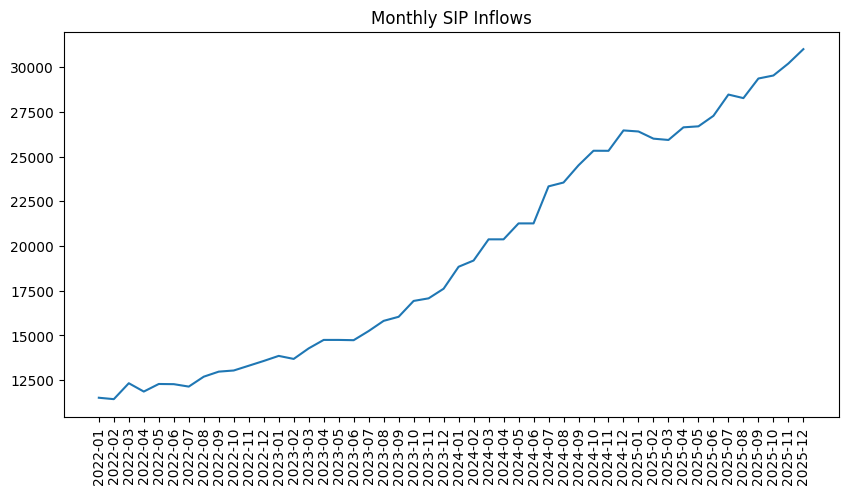

In [ ]:
import matplotlib.pyplot as plt

sip = datasets['04_monthly_sip_inflows.csv']

plt.figure(figsize=(10,5))
plt.plot(sip['month'], sip['sip_inflow_crore'])
plt.xticks(rotation=90)
plt.title("Monthly SIP Inflows")
plt.show()

In [ ]:
txn = datasets['08_investor_transactions.csv']

txn['transaction_type'].value_counts()

,count
transaction_type,
SIP,19716
Lumpsum,8095
Redemption,4967


In [ ]:
txn['state'].value_counts().head(10)

,count
state,
Punjab,2965
Madhya Pradesh,2931
Tamil Nadu,2806
Gujarat,2780
West Bengal,2748
Haryana,2736
Telangana,2718
Uttar Pradesh,2695
Delhi,2677


In [ ]:
txn['age_group'].value_counts()

,count
age_group,
26-35,13463
36-45,8146
18-25,4916
46-55,3779
56+,2474


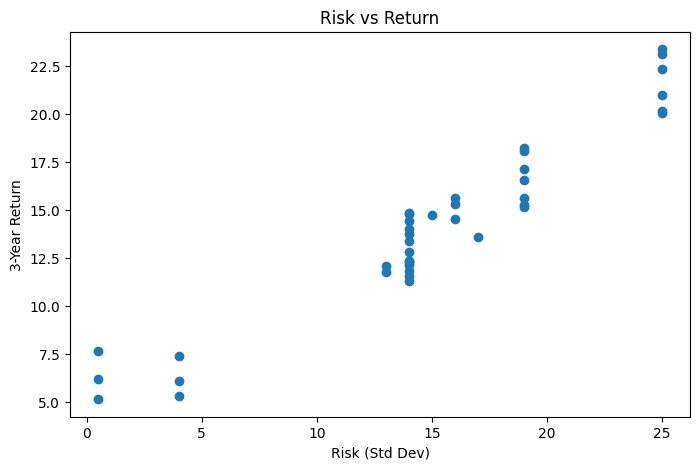

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    perf['std_dev_ann_pct'],
    perf['return_3yr_pct']
)

plt.xlabel("Risk (Std Dev)")
plt.ylabel("3-Year Return")
plt.title("Risk vs Return")
plt.show()

EDA Findings

1. Top mutual funds by AUM are dominated by mid-cap and small-cap funds.

2. SIP is the most popular transaction type with 19,716 transactions.

3. Punjab, Madhya Pradesh, and Tamil Nadu recorded the highest transaction counts.

4. Investors aged 26–35 represent the largest investing group.

5. Younger investors show stronger participation in mutual fund investments compared to older age groups.

In [ ]:
perf = datasets['07_scheme_performance.csv']

perf.groupby('fund_house')['return_3yr_pct'].mean().sort_values(
    ascending=False
)

,return_3yr_pct
fund_house,
DSP Mutual Fund,16.686667
SBI Mutual Fund,15.252000
Axis Mutual Fund,15.035000
UTI Mutual Fund,14.350000
Mirae Asset MF,14.316667
Aditya Birla Sun Life MF,13.766667
HDFC Mutual Fund,13.492000
ICICI Prudential MF,13.294000
Kotak Mahindra MF,13.077500


In [ ]:
fund_master = datasets['01_fund_master.csv']

fund_master['risk_category'].value_counts()

,count
risk_category,
Moderate,16
High,8
Very High,6
Low,6
Moderately High,4


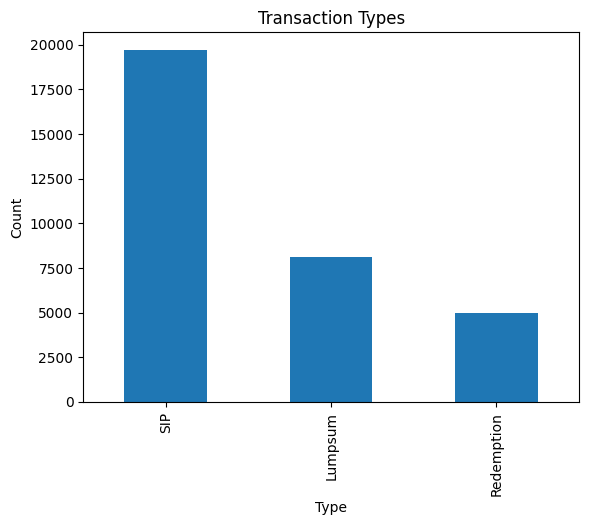

In [ ]:
import matplotlib.pyplot as plt

txn['transaction_type'].value_counts().plot(kind='bar')

plt.title("Transaction Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

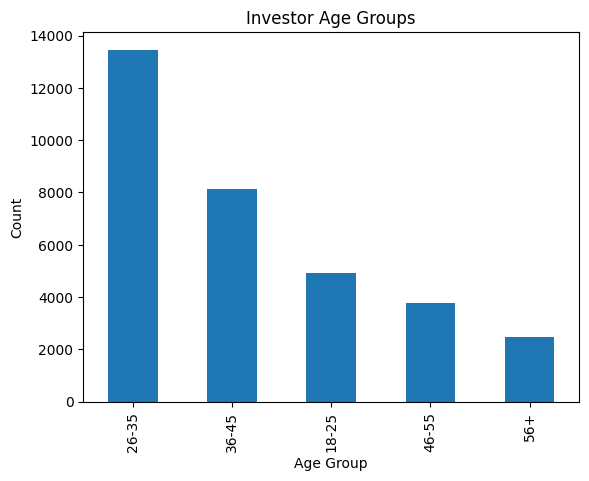

In [ ]:
txn['age_group'].value_counts().plot(kind='bar')

plt.title("Investor Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

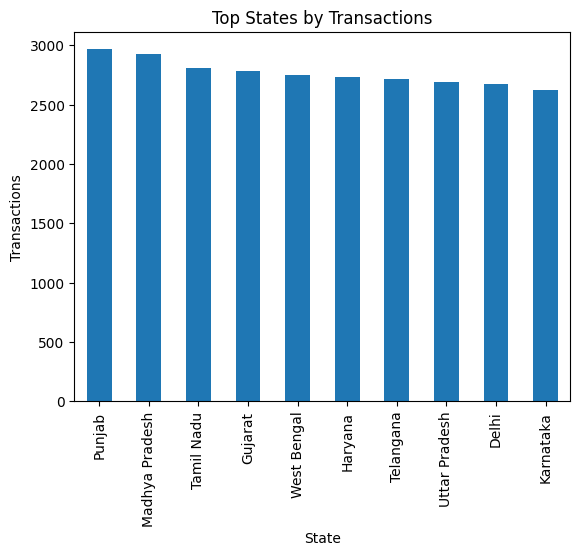

In [ ]:
txn['state'].value_counts().head(10).plot(kind='bar')

plt.title("Top States by Transactions")
plt.xlabel("State")
plt.ylabel("Transactions")
plt.show()

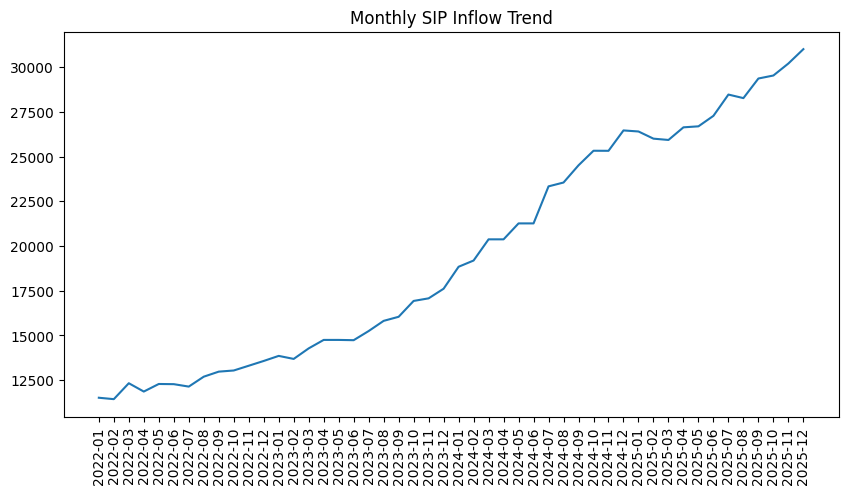

In [ ]:
sip = pd.read_csv("04_monthly_sip_inflows.csv")

plt.figure(figsize=(10,5))
plt.plot(sip['month'], sip['sip_inflow_crore'])

plt.title("Monthly SIP Inflow Trend")
plt.xticks(rotation=90)
plt.show()

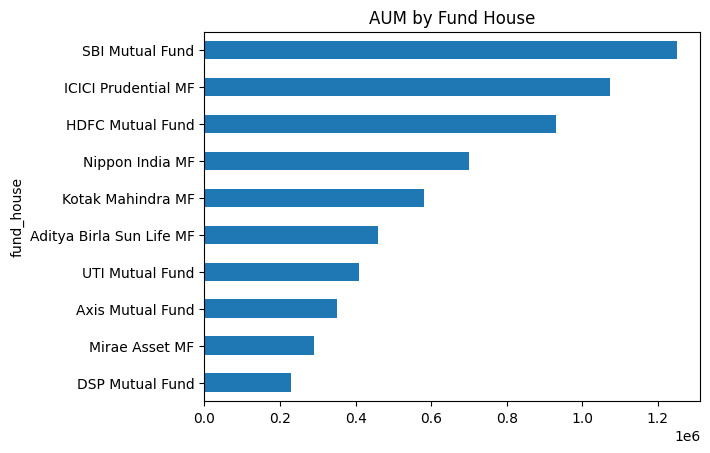

In [ ]:
aum = pd.read_csv("03_aum_by_fund_house.csv")

latest = aum.groupby('fund_house')['aum_crore'].max()

latest.sort_values().plot(kind='barh')

plt.title("AUM by Fund House")
plt.show()

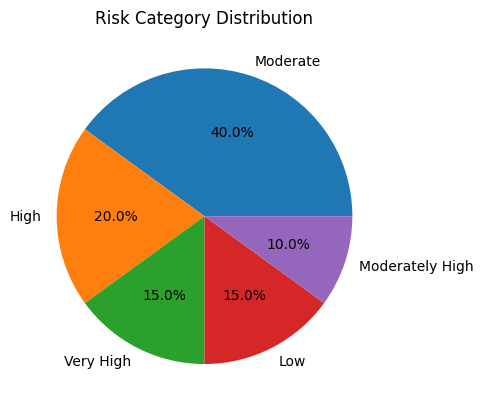

In [ ]:
import matplotlib.pyplot as plt

perf['risk_grade'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Risk Category Distribution")
plt.ylabel("")
plt.show()

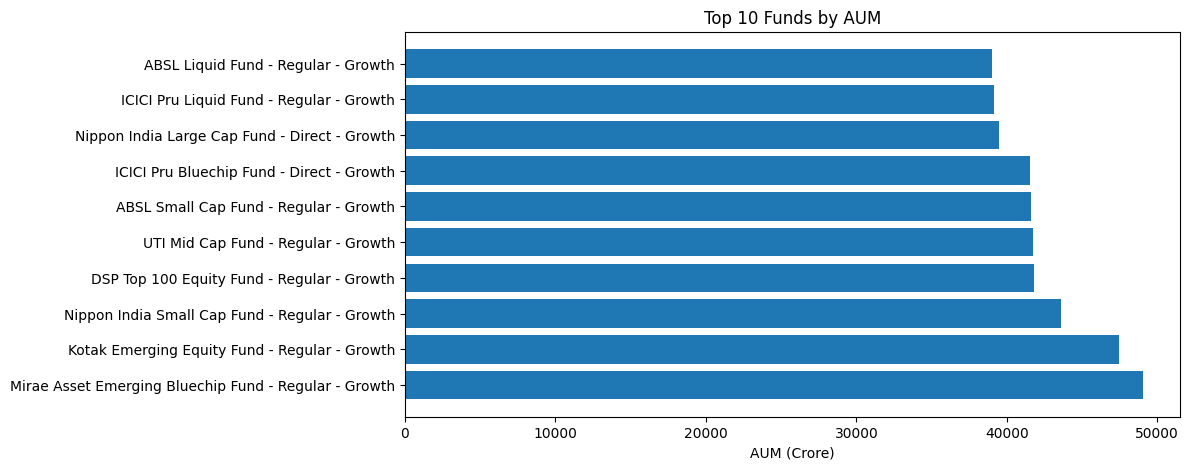

In [ ]:
top10 = perf[['scheme_name','aum_crore']].sort_values(
    by='aum_crore',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.barh(top10['scheme_name'], top10['aum_crore'])

plt.title("Top 10 Funds by AUM")
plt.xlabel("AUM (Crore)")
plt.show()

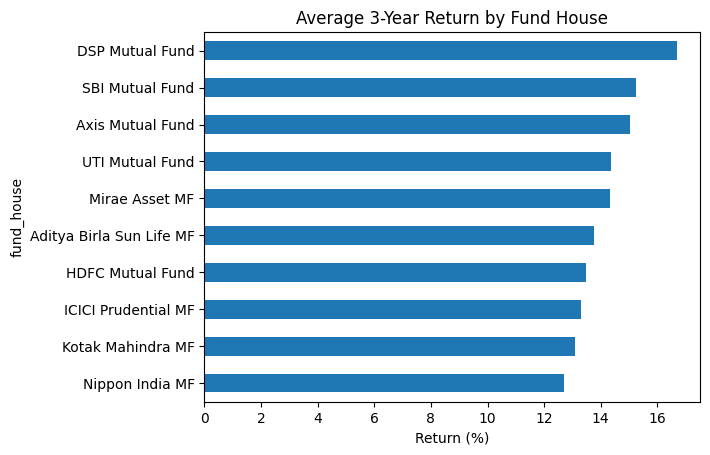

In [ ]:
fund_returns = perf.groupby('fund_house')['return_3yr_pct'].mean()

fund_returns.sort_values().plot(kind='barh')

plt.title("Average 3-Year Return by Fund House")
plt.xlabel("Return (%)")
plt.show()

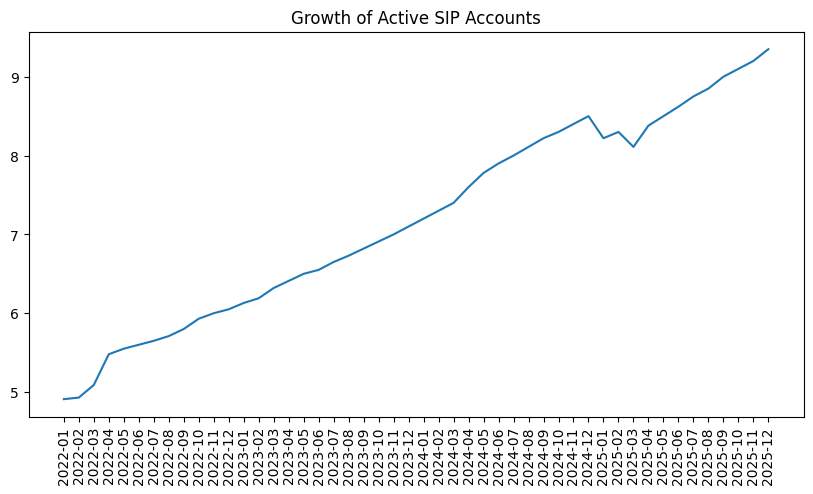

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    sip['month'],
    sip['active_sip_accounts_crore']
)

plt.xticks(rotation=90)
plt.title("Growth of Active SIP Accounts")
plt.show()

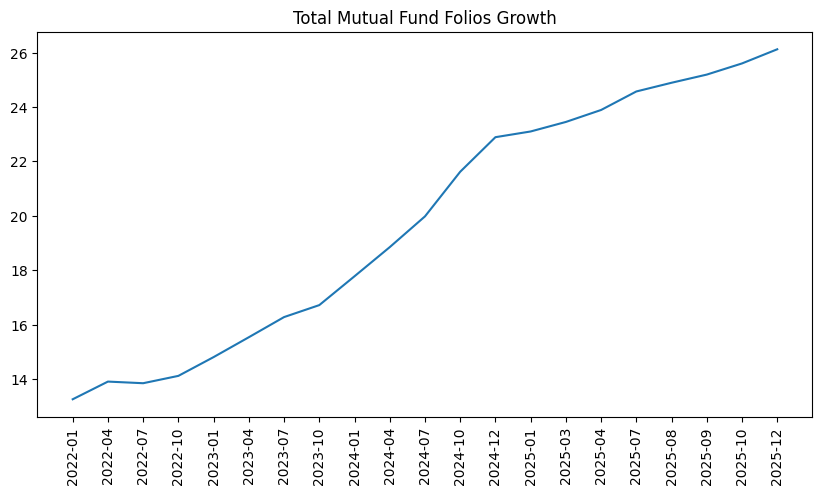

In [ ]:
folio = pd.read_csv("06_industry_folio_count.csv")

plt.figure(figsize=(10,5))

plt.plot(
    folio['month'],
    folio['total_folios_crore']
)

plt.xticks(rotation=90)
plt.title("Total Mutual Fund Folios Growth")
plt.show()

In [ ]:
import pandas as pd

perf = pd.read_csv("07_scheme_performance.csv")

perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [ ]:
perf[['scheme_name','sharpe_ratio']]\
.sort_values(by='sharpe_ratio', ascending=False)\
.head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


In [ ]:
perf[['scheme_name','alpha']]\
.sort_values(by='alpha', ascending=False)\
.head(10)

,scheme_name,alpha
9,HDFC Short Term Debt Fund - Regular - Growth,1.98
21,Kotak Emerging Equity Fund - Regular - Growth,1.91
14,ICICI Pru Liquid Fund - Regular - Growth,1.85
22,Kotak Flexicap Fund - Regular - Growth,1.85
29,ABSL Small Cap Fund - Regular - Growth,1.84
37,DSP Top 100 Equity Fund - Regular - Growth,1.82
18,Nippon India ETF Nifty 50 BeES,1.80
33,UTI Flexi Cap Fund - Regular - Growth,1.79
1,SBI Bluechip Fund - Direct Plan - Growth,1.78
35,Mirae Asset Emerging Bluechip Fund - Regular -...,1.70


In [ ]:
perf[['scheme_name','std_dev_ann_pct']]\
.sort_values(by='std_dev_ann_pct')\
.head(10)

,scheme_name,std_dev_ann_pct
14,ICICI Pru Liquid Fund - Regular - Growth,0.5
23,Kotak Liquid Fund - Regular - Growth,0.5
30,ABSL Liquid Fund - Regular - Growth,0.5
4,SBI Magnum Gilt Fund - Regular Plan - Growth,4.0
9,HDFC Short Term Debt Fund - Regular - Growth,4.0
19,Nippon India Gilt Securities Fund - Regular - ...,4.0
18,Nippon India ETF Nifty 50 BeES,13.0
31,UTI Nifty 50 Index Fund - Regular - Growth,13.0
15,Nippon India Large Cap Fund - Regular - Growth,14.0
10,ICICI Pru Bluechip Fund - Regular - Growth,14.0


In [ ]:
perf[['scheme_name','return_5yr_pct']]\
.sort_values(by='return_5yr_pct', ascending=False)\
.head(10)

,scheme_name,return_5yr_pct
29,ABSL Small Cap Fund - Regular - Growth,23.80
27,Axis Small Cap Fund - Regular - Growth,22.62
17,Nippon India Small Cap Fund - Regular - Growth,21.88
3,SBI Small Cap Fund - Direct Plan - Growth,21.82
2,SBI Small Cap Fund - Regular Plan - Growth,20.67
39,DSP Small Cap Fund - Regular - Growth,20.61
38,DSP Midcap Fund - Regular - Growth,19.00
26,Axis Midcap Fund - Regular - Growth,18.94
21,Kotak Emerging Equity Fund - Regular - Growth,17.75
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,17.69


In [ ]:
perf[['scheme_name','sortino_ratio']]\
.sort_values(by='sortino_ratio', ascending=False)\
.head(10)

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


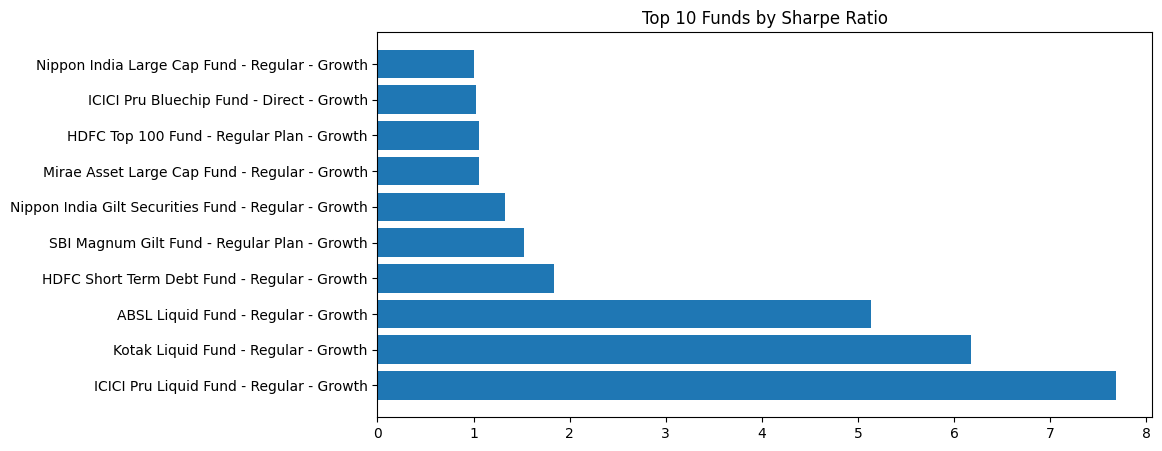

In [ ]:
import matplotlib.pyplot as plt

top_sharpe = perf.sort_values(
    by='sharpe_ratio',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.barh(
    top_sharpe['scheme_name'],
    top_sharpe['sharpe_ratio']
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.show()

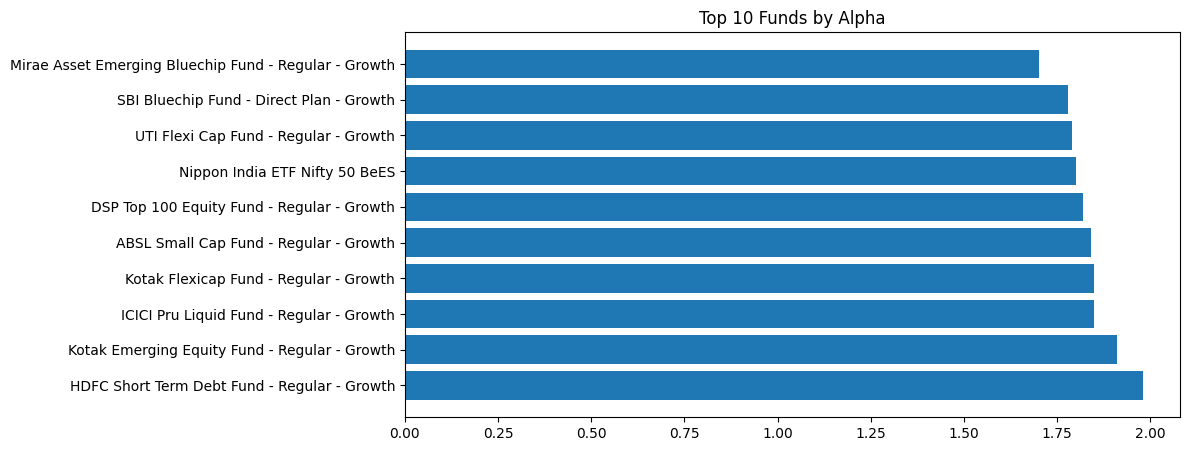

In [ ]:
top_alpha = perf.sort_values(
    by='alpha',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.barh(
    top_alpha['scheme_name'],
    top_alpha['alpha']
)

plt.title("Top 10 Funds by Alpha")
plt.show()

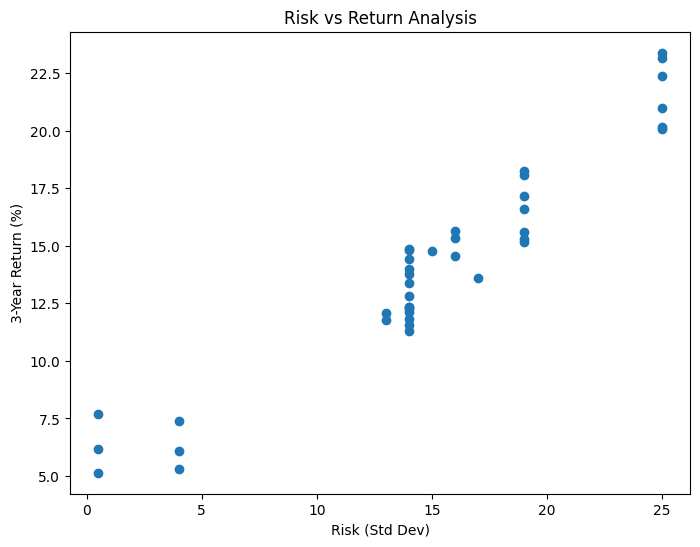

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    perf['std_dev_ann_pct'],
    perf['return_3yr_pct']
)

plt.xlabel("Risk (Std Dev)")
plt.ylabel("3-Year Return (%)")
plt.title("Risk vs Return Analysis")

plt.show()

In [ ]:
import pandas as pd

scheme_perf = pd.read_csv("07_scheme_performance.csv")

In [ ]:
top_returns = scheme_perf.sort_values(
    by='return_3yr_pct',
    ascending=False
)[['scheme_name', 'fund_house', 'return_3yr_pct']]

top_returns.head(10)

,scheme_name,fund_house,return_3yr_pct
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,23.39
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,23.14
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,22.38
27,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,20.98
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,20.15
39,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,20.08
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,18.23
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,18.08
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,17.16
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,16.58


In [ ]:
top_returns.head(10).to_csv(
    "top_10_funds_by_return.csv",
    index=False
)

print("File saved successfully!")

File saved successfully!


In [ ]:
top_returns.head(10)

,scheme_name,fund_house,return_3yr_pct
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,23.39
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,23.14
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,22.38
27,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,20.98
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,20.15
39,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,20.08
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,18.23
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,18.08
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,17.16
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,16.58


In [ ]:
top_sharpe = scheme_perf.sort_values(
    by='sharpe_ratio',
    ascending=False
)[['scheme_name', 'fund_house', 'sharpe_ratio']]

top_sharpe.head(10)

,scheme_name,fund_house,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,1.03
15,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.00


In [ ]:
top_sharpe.head(10).to_csv(
    "top_10_sharpe_funds.csv",
    index=False
)

In [ ]:
top_sharpe.head(10)

,scheme_name,fund_house,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,1.03
15,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.00


In [ ]:
top_alpha = scheme_perf.sort_values(
    by='alpha',
    ascending=False
)[['scheme_name', 'fund_house', 'alpha']]

top_alpha.head(10)

,scheme_name,fund_house,alpha
9,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,1.98
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,1.91
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,1.85
22,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,1.85
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,1.84
37,DSP Top 100 Equity Fund - Regular - Growth,DSP Mutual Fund,1.82
18,Nippon India ETF Nifty 50 BeES,Nippon India MF,1.80
33,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,1.79
1,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,1.78
35,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,1.70


In [ ]:
top_alpha.head(10).to_csv(
    "top_10_alpha_funds.csv",
    index=False
)

In [ ]:
top_alpha.head(10)

,scheme_name,fund_house,alpha
9,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,1.98
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,1.91
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,1.85
22,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,1.85
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,1.84
37,DSP Top 100 Equity Fund - Regular - Growth,DSP Mutual Fund,1.82
18,Nippon India ETF Nifty 50 BeES,Nippon India MF,1.80
33,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,1.79
1,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,1.78
35,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,1.70


In [ ]:
top_beta = scheme_perf.sort_values(
    by='beta',
    ascending=False
)[['scheme_name', 'fund_house', 'beta']]

top_beta.head(10)

,scheme_name,fund_house,beta
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,1.04
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,1.04
18,Nippon India ETF Nifty 50 BeES,Nippon India MF,1.04
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,1.03
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,1.03
28,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,1.03
16,Nippon India Large Cap Fund - Direct - Growth,Nippon India MF,1.02
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,1.00
33,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,1.00
26,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,1.00


In [ ]:
top_beta.head(10).to_csv(
    "top_10_beta_funds.csv",
    index=False
)

In [ ]:
top_beta.head(10)

,scheme_name,fund_house,beta
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,1.04
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,1.04
18,Nippon India ETF Nifty 50 BeES,Nippon India MF,1.04
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,1.03
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,1.03
28,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,1.03
16,Nippon India Large Cap Fund - Direct - Growth,Nippon India MF,1.02
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,1.00
33,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,1.00
26,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,1.00


In [ ]:
top_drawdown = scheme_perf.sort_values(
    by='max_drawdown_pct'
)[['scheme_name', 'fund_house', 'max_drawdown_pct']]

top_drawdown.head(10)

,scheme_name,fund_house,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,-33.15
26,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,-30.87
24,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,-27.54
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,-26.99
18,Nippon India ETF Nifty 50 BeES,Nippon India MF,-26.75
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,-26.59
10,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,-25.91


In [ ]:
top_drawdown.head(10).to_csv(
    "worst_drawdown_funds.csv",
    index=False
)

In [ ]:
top_drawdown.head(10)

,scheme_name,fund_house,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,-33.15
26,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,-30.87
24,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,-27.54
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,-26.99
18,Nippon India ETF Nifty 50 BeES,Nippon India MF,-26.75
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,-26.59
10,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,-25.91


In [ ]:
summary_stats = scheme_perf[
    ['return_3yr_pct',
     'alpha',
     'beta',
     'sharpe_ratio',
     'max_drawdown_pct']
].describe()

summary_stats

,return_3yr_pct,alpha,beta,sharpe_ratio,max_drawdown_pct
count,40.000000,40.000000,40.000000,40.000000,40.000000
mean,14.089000,1.253500,0.873250,1.361750,-19.200250
std,4.617253,0.447412,0.224846,1.475805,8.819164
min,5.140000,0.510000,0.220000,0.800000,-33.500000
25%,12.035000,0.887500,0.890000,0.865000,-25.062500
50%,14.205000,1.205000,0.960000,0.925000,-20.600000
75%,15.882500,1.700000,1.000000,0.985000,-14.255000
max,23.390000,1.980000,1.040000,7.680000,-2.230000


In [ ]:
summary_stats.to_csv("summary_statistics.csv")
print("Summary statistics saved!")

Summary statistics saved!
